## Load notebook

### Python modules

In [1]:
# standard libs
import numpy as np
import pandas as pd
from scipy import sparse
import lmfit as lm
from tqdm import tqdm
import io, sys, importlib
from contextlib import redirect_stdout

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18

# XPCS library
sys.path.append('./XPCSlibrary/')

import ID10tools as ID10
from ID10tools import Nx, Ny, Npx
importlib.reload(ID10)
ID10.set_version('v2')

import XPCStools as XPCS
from XPCStools import E2lambda, lambda2E, theta2Q, Q2theta, decorrelation_f
importlib.reload(XPCS)
XPCS.set_beamline('ID10')

import COSMICRAYtools as COSMIC
importlib.reload(COSMIC)
COSMIC.set_beamline('ID10')

#### EXPERIMENTAL VARIABLES ####
XPCS.set_expvar(1350, 1350, 7.1)
ID10.Nfmax_dense_file = 2000
ID10.Nfmax_sparse_file = 5000
################################

###### FOLDER PATHS ######
from folder_paths import *
##########################

### Functions

In [2]:
def plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True):

    print("Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan")    

    if t1_fit is None: t1_fit = 0
    if t2_fit is None: t2_fit = 1e100
    
    g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])

    # DATA PLOTS
    plt.figure(figsize=(10,5))
    plt.scatter(g2[0], g2[1], s=1, c='C0')
    t_mt, g2_mt, dg2_mt = XPCS.get_g2mt_fromling2(itime, g2[1], g2[2])
    plt.errorbar(t_mt, g2_mt, yerr=dg2_mt, fmt = 'o', c='C1')

    tmask = (t1_fit<g2[0])*(g2[0]<t2_fit)
    x, y, dy =  g2[0][tmask], g2[1][tmask], g2[2][tmask]

    # FIT
    fit = model.fit(y, params, t=x, method='least_squares', weights=1/dy)
    g2fit.loc[0] = [Q_notebook, dQ_notebook,
                    fit.params['tau'].value, fit.params['tau'].stderr, fit.params['tau'].stderr/fit.params['tau'].value*100,
                    fit.params['beta'].value, fit.params['beta'].stderr, fit.params['beta'].stderr/fit.params['beta'].value*100,
                    fit.params['c'].value, fit.params['c'].stderr, fit.params['c'].stderr/fit.params['c'].value*100,
                    fit.params['y0'].value, fit.params['y0'].stderr, fit.params['y0'].stderr/fit.params['y0'].value*100,
                    fit.redchi,]
    if save: g2fit.to_csv(f"{g2fit4damaged_vGeO2_folder}g2fit-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", index=False)
    display(g2fit)

    # PLOT FIT
    x = np.arange(np.min(g2[0]), np.max(g2[0]), 1e-2)
    y = fit.eval(t=x)
    plt.plot(x, y, c='black', linestyle='--')
    if t1_fit!=0:     plt.axvline(t1_fit, color='red', linestyle='--')
    if t2_fit!=1e100: plt.axvline(t2_fit, color='red', linestyle='--')

    plt.xlabel('t [s]')
    plt.ylabel('g2')
    plt.xscale('log')


def plotfit_bydose(itime, Lbin, g2, t1_fit, t2_fit):

    print("Using Global variables: Nbunch, model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan")   
    
    if t1_fit is None: t1_fit = 0
    if t2_fit is None: t2_fit = 1e100
    if Lbin is None: Lbin=1

    g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])
    g2fit.index.name = 'tw'

    plt.figure(figsize=(10,5))
    for i,k in enumerate(g2.keys()):
        t_mt, g2_mt, dg2_mt = XPCS.get_g2mt_fromling2(itime*Lbin, g2[k][1], g2[k][2])
        plt.scatter(g2[k][0], g2[k][1], s=1, c='C'+str(i))
        plt.errorbar(t_mt, g2_mt, yerr=dg2_mt, fmt = 'o', c='C'+str(i), label =f'd = {k}s')
        
        tmask = (t1_fit<g2[k][0])*(g2[k][0]<t2_fit)
        x, y, dy =  g2[k][0][tmask], g2[k][1][tmask], g2[k][2][tmask]
        
        fit = model.fit(y, params, t=x, method='least_squares', weights=1/dy)
        g2fit.loc[k] = [Q_notebook, dQ_notebook,
                        fit.params['tau'].value, fit.params['tau'].stderr, fit.params['tau'].stderr/fit.params['tau'].value*100,
                        fit.params['beta'].value, fit.params['beta'].stderr, fit.params['beta'].stderr/fit.params['beta'].value*100,
                        fit.params['c'].value, fit.params['c'].stderr, fit.params['c'].stderr/fit.params['c'].value*100,
                        fit.params['y0'].value, fit.params['y0'].stderr, fit.params['y0'].stderr/fit.params['y0'].value*100,
                        fit.redchi,]

        x = np.arange(np.min(g2[k][0]), np.max(g2[k][0]), 1e-2)
        y = fit.eval(t=x)
        plt.plot(x, y,)

    if t1_fit!=0:     plt.axvline(t1_fit, color='red', linestyle='--')
    if t2_fit!=1e100: plt.axvline(t2_fit, color='red', linestyle='--')

    plt.xlabel('t [s]')
    plt.ylabel('g2')
    plt.xscale('log')
    plt.ylim(1, 1.04)
    plt.legend()
    plt.tight_layout(); plt.show()

    display(g2fit)

    if Nbunch != 1:
        plt.figure(figsize=(10,5))
        plt.title('tau')
        plt.errorbar(g2fit.index, g2fit.tau,  yerr=g2fit.dtau, fmt='o')
        plt.xlabel('t [s]')
        plt.ylabel('tau [s]')
        plt.xlim(0)
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(10,5))
        plt.title('beta')
        plt.errorbar(g2fit.index, g2fit.beta,  yerr=g2fit.dbeta, fmt='o')
        plt.xlabel('t [s]')
        plt.ylabel('beta')
        plt.xlim(0)
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(10,5))
        plt.title('c')
        plt.errorbar(g2fit.index, g2fit.c,  yerr=g2fit.dc, fmt='o')
        plt.xlabel('t [s]')
        plt.ylabel('c')
        plt.xlim(0)
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(10,5))
        plt.title('y0')
        plt.errorbar(g2fit.index, g2fit.y0,  yerr=g2fit.dy0, fmt='o')
        plt.xlabel('t [s]')
        plt.ylabel('y0')
        plt.tight_layout(); plt.show()

### Load masks

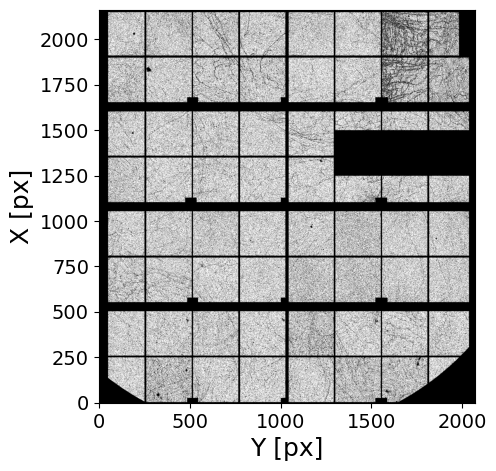

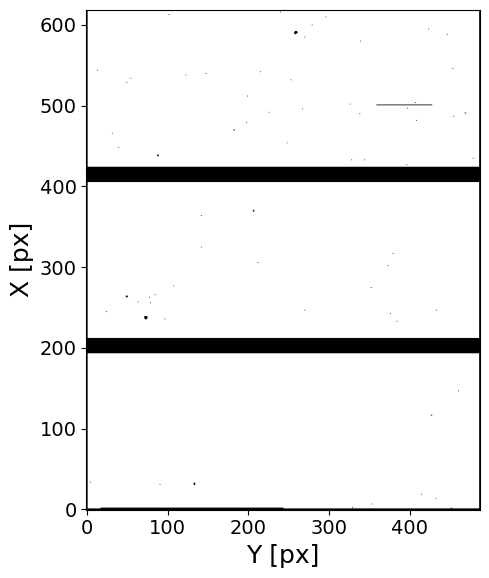

In [3]:
### e4m MASKS
e4m_htmask = np.load(MASKS_folder+'e4m_htmask-GeO2_3_240C_0001_0004'+'.npy')
e4m_mask = np.load(MASKS_folder+'e4m_mask'+'.npy')

plt.figure(figsize=(5, 5))
plt.imshow((e4m_mask*e4m_htmask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.tight_layout(); plt.show()

### pilatus MASKS
pilatus_mask = np.load(MASKS_folder+'pilatus300k_mask_20240201'+'.npy').astype(bool)

plt.figure(figsize=(6, 6))
plt.imshow(~pilatus_mask, cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.tight_layout(); plt.show()

### Beamstop mask

In [4]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan =12
Nfi, Nff = 0, 1000
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, )

#############################
command = mtimescan 0.02 1 220000
Ei = 9.699998837562536
itime = 0.0201
theta = 1.7500000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1 loops)


Done! (elapsed time = 0.29 s)
Concatenating vectors ...
Done! (elapsed time = 0.08 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6/GeO2_6_0001/scan0012/
	 | Shape:       (1000, 4471016)
	 | Sparsity:     3.8e-03
	 | Memory usage (scipy.csr_array): 0.192 GB (np.array usage: 16.656 GB)


################################################################################
Maximum count in the whole run -> 4689.0
# of pixels above Ith_high treshold ->  23489 pixels (of 4471016 => 0.53 %)
################################################################################



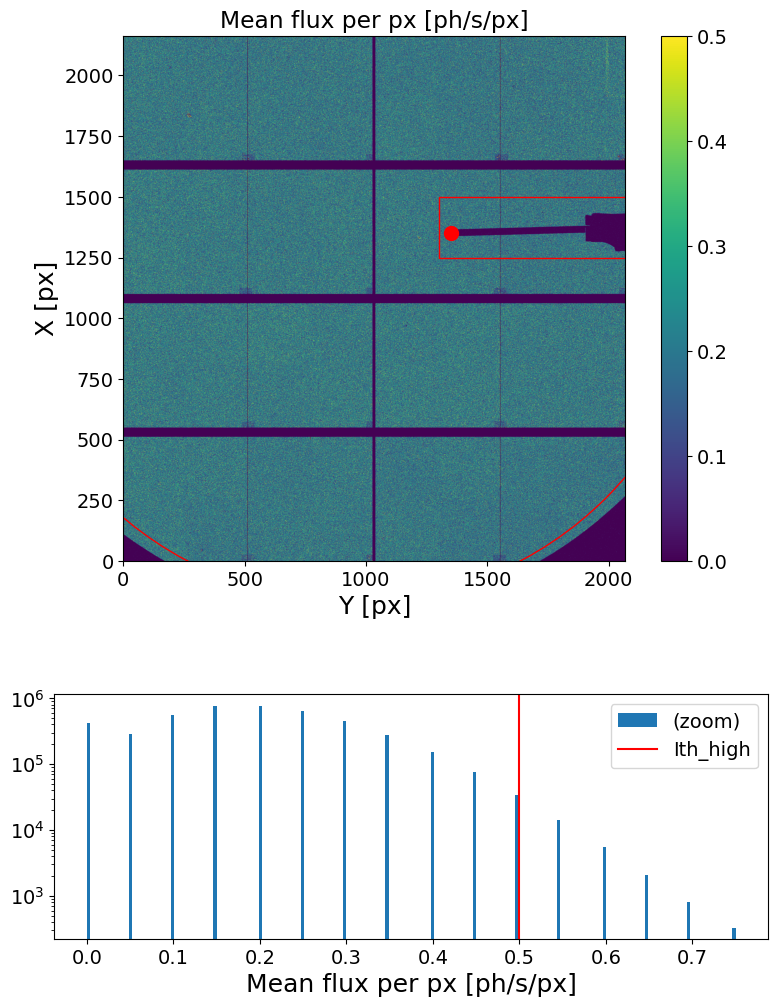

In [5]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.5, mask_geom=geom,)

#################################################
Masked area =  93.74594052000708 %
#################################################



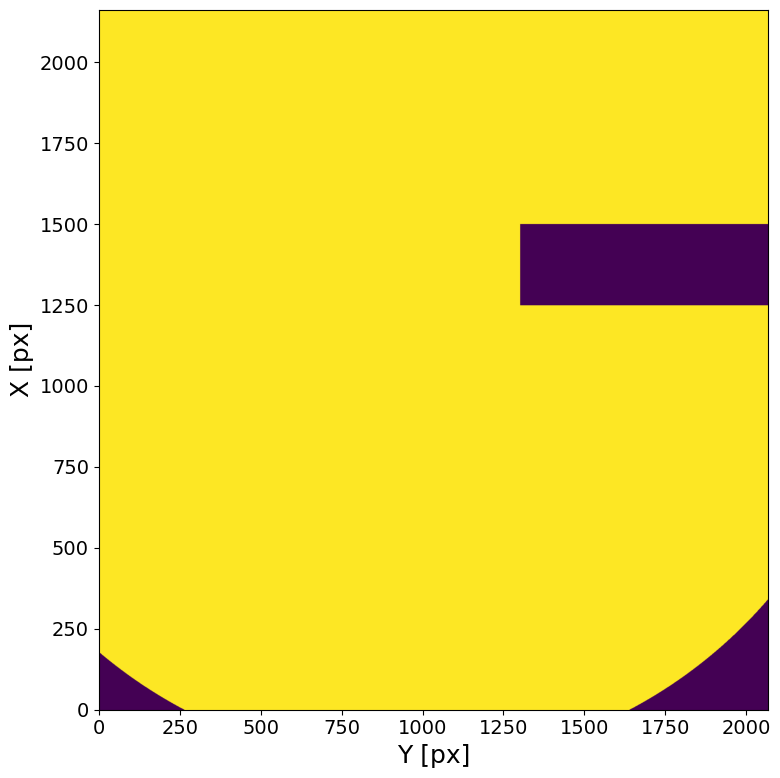

In [6]:
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Q mask

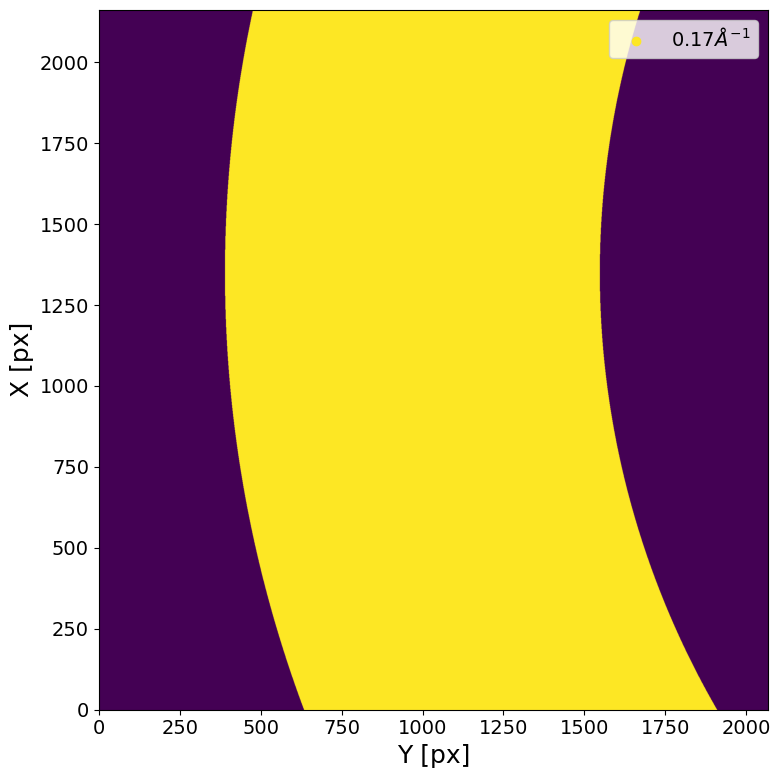

In [7]:
###################
Q_notebook = .17 # [.21, .19, .17, .15, .13]
dQ_notebook = .03 # => Q_width = 2*dQ
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Q_notebook, dQ_notebook, Qmap_plot=False)

# Multitau - linear correlation comparison

## Load test XPCS scan
Start the Temperature ramp!

In [18]:
# 'GeO2_6', 1, 12
#######################################
sample_name = 'GeO2_7_100C' 
Ndataset = 1
Nscan =3
Nfi, Nff = None, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=50, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 33.01 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00021.h5 (22/361 loops)
	 -> loading file	 -> loading file eiger4m_v2_sparse_frame_0_00018.h5  eiger4m_v2_sparse_frame_0_00016.h5(19/361 loops) 
(17/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00017.h5 (18/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00014.h5 (15/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_000

## Flux check

################################################################################
Maximum count in the whole run -> 3.0
# of pixels above Ith_high treshold ->  3264046 pixels (of 4471016 => 73.0 %)
# of pixels below Ith_low treshold ->  95684 pixels (of 4471016 => 2.14 %)
################################################################################



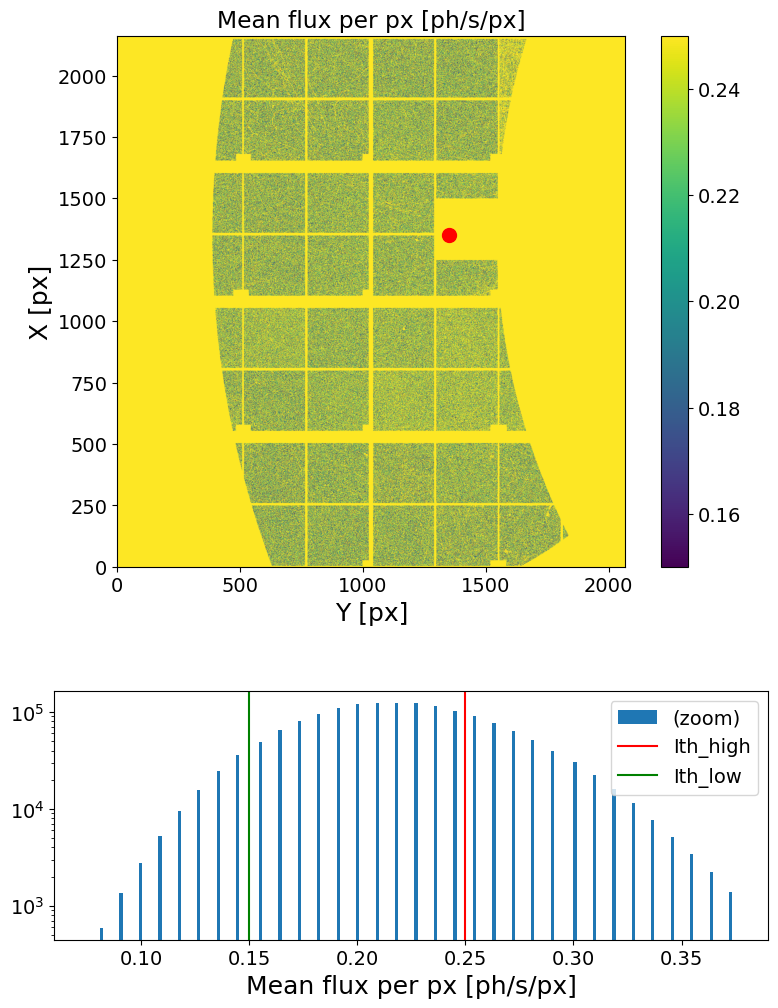

In [16]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=.15, Ith_high=.25, Nff=100_000, load_mask=load_mask)

## Intensity analysis

In [17]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))

<SecondaryAxis: >

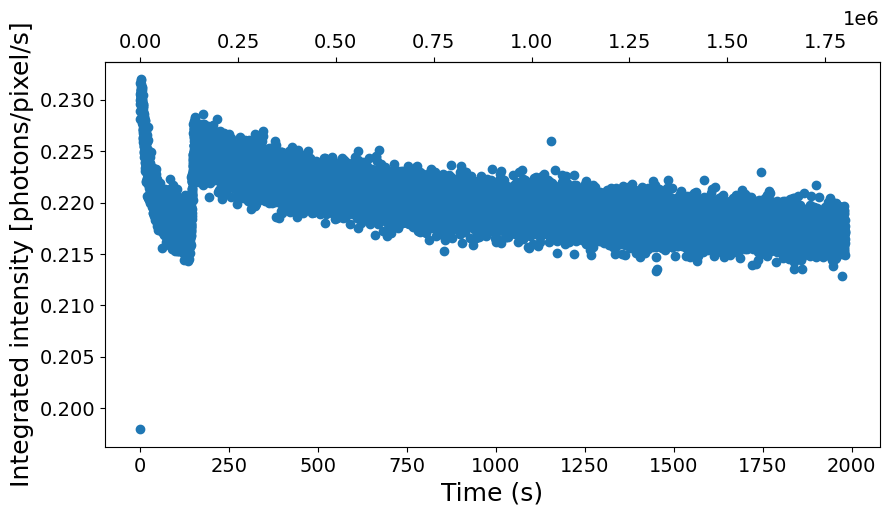

In [18]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

## Linear correlation of damaged-vGeO2

In [159]:
############################
Nfi = int(0.25e6)
Nff = Nfi +  1_000_000
Lbin=10
############################

G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=Nfi, Nff=Nff, Lbin=Lbin)
g2 = np.vstack(XPCS.get_g2(itime*Lbin, G2t))
del G2t

Loading frames ...
Done! (elapsed time = 4.85 s)
Binning frames (Lbin = 10, using MKL library) ...
Done! (elapsed time = 4.04 s)
	 | 100000 frames X 1631929 pixels
	 | sparsity = 2.42e-03
	 | memory usage (sparse.csr_array @ float32) = 4.416 GB
Computing G2t (using MKL library)...
Done! (elapsed time = 37.84 s)
	 | 100000 X 100000 squared matrix
	 | memory usage (np.array @ float32) = 37.253 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 4.75 s)

Computing g2 (using cython code)...
Done! (elapsed time = 8.57 s)



,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.17,0.03,5.780185,0.070983,1.228047,0.721896,0.006066,0.840243,0.027822,0.000191,0.686962,1.001467,0.000005,0.000482,0.994281


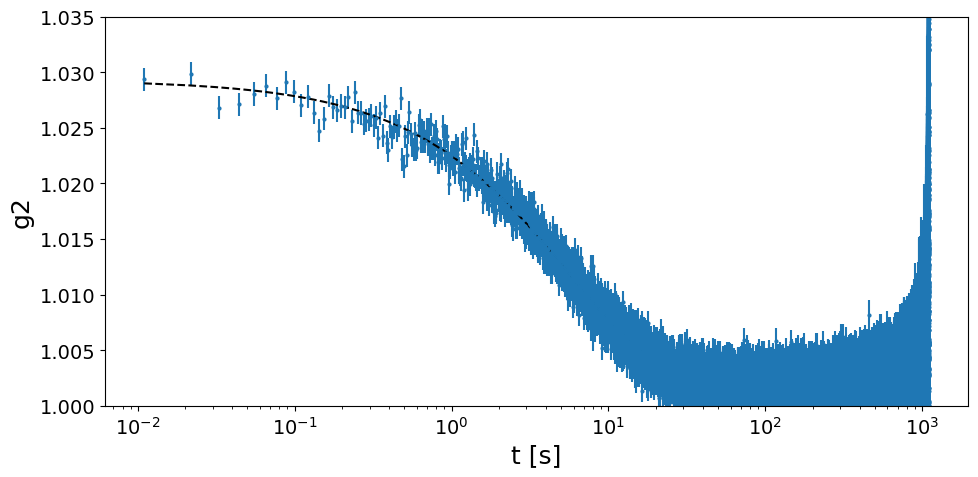

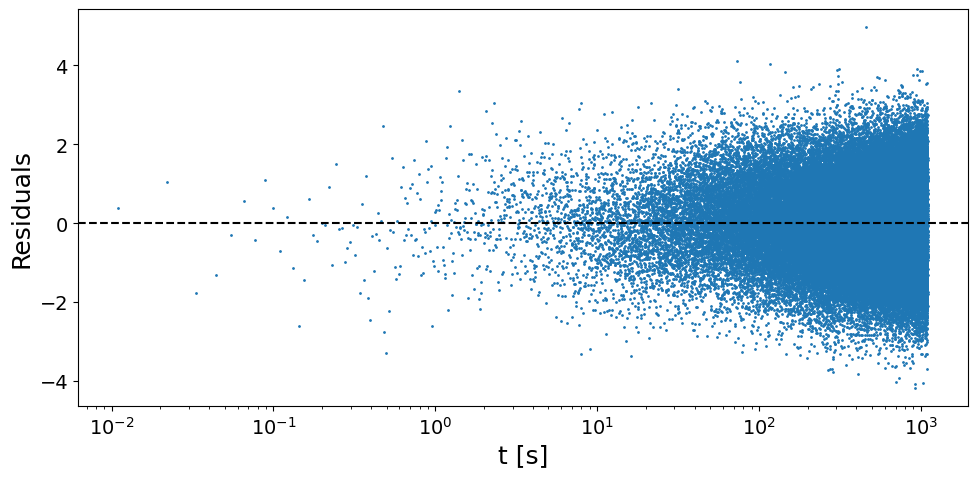

In [160]:
##################
t1_fit = None
t2_fit = None
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

if t1_fit is None: t1_fit = 0
if t2_fit is None: t2_fit = 1e100

g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])

# DATA PLOTS
plt.figure(figsize=(10,5))
plt.errorbar(g2[0], g2[1], yerr=g2[2], fmt = 'o', c='C0', label='g2 data', markersize=2)

tmask = (t1_fit<g2[0])*(g2[0]<t2_fit)
x, y, dy =  g2[0][tmask], g2[1][tmask], g2[2][tmask]

# FIT
fit = model.fit(y, params, t=x, method='least_squares', weights=1/dy)
g2fit.loc[0] = [Q_notebook, dQ_notebook,
                fit.params['tau'].value, fit.params['tau'].stderr, fit.params['tau'].stderr/fit.params['tau'].value*100,
                fit.params['beta'].value, fit.params['beta'].stderr, fit.params['beta'].stderr/fit.params['beta'].value*100,
                fit.params['c'].value, fit.params['c'].stderr, fit.params['c'].stderr/fit.params['c'].value*100,
                fit.params['y0'].value, fit.params['y0'].stderr, fit.params['y0'].stderr/fit.params['y0'].value*100,
                fit.redchi,]

display(g2fit)

# PLOT FIT
xp = np.arange(np.min(g2[0]), np.max(g2[0]), 1e-2)
yp = fit.eval(t=xp)
plt.plot(xp, yp, c='black', linestyle='--')
if t1_fit!=0:     plt.axvline(t1_fit, color='red', linestyle='--')
if t2_fit!=1e100: plt.axvline(t2_fit, color='red', linestyle='--')

plt.xlabel('t [s]')
plt.ylabel('g2')
plt.xscale('log')
plt.ylim(1, 1.035)
#plt.xlim(np.min(g2[0]), t2_fit)
plt.tight_layout(); plt.show()

# RESIDUALS
plt.figure(figsize=(10,5))
plt.scatter(x, fit.residual, s=1, c='C0')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('t [s]')
plt.ylabel('Residuals')
plt.xscale('log')
#plt.xlim(np.min(g2[0]), t2_fit)
plt.tight_layout(); plt.show()


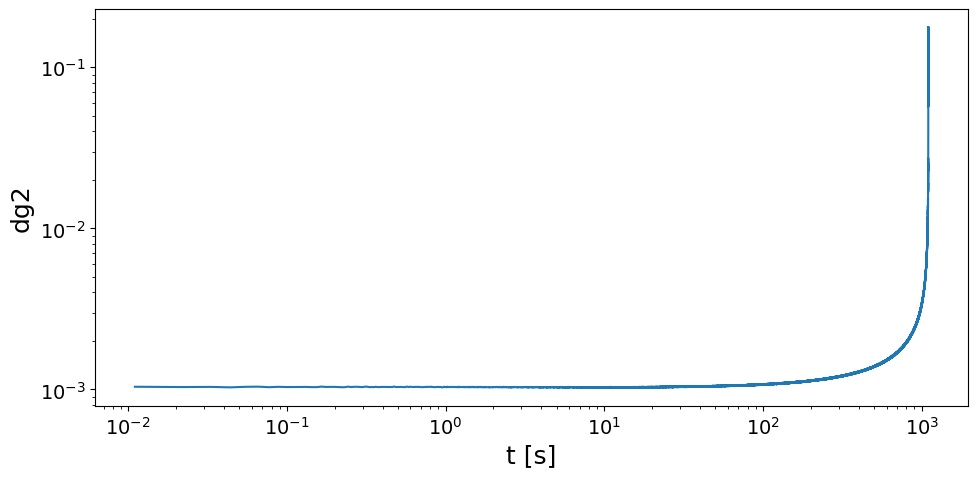

In [161]:
plt.figure(figsize=(10,5))
plt.plot(g2[0], g2[2])
plt.yscale('log')
plt.xscale('log')
plt.xlabel('t [s]')
plt.ylabel('dg2')
plt.tight_layout()

## Multitau correlation of damaged-vGeO2

In [155]:
XPCS.print_Nf_choices(e4m_data.shape[0]-.25e6)

       Nf = 1550288.0    =>    log2(Nf) = 20.56
----------------------------------------------------


,red Nf,sparse depth,subG2t mem (GBy),thrown frames %,thrown frames
0,2**20,20,4096.0,32.4,501712.0
1,2*2**19,19,1024.0,32.4,501712.0
2,5*2**18,18,256.0,15.5,239568.0
3,11*2**17,17,64.0,7.0,108496.0
4,23*2**16,16,16.0,2.8,42960.0
5,47*2**15,15,4.0,0.7,10192.0
6,94*2**14,14,1.0,0.7,10192.0
7,189*2**13,13,0.2,0.1,2000.0
8,378*2**12,12,0.1,0.1,2000.0


----------------------------------------------------


In [185]:
import importlib
importlib.reload(XPCS)

<module 'XPCStools' from '/mnt/data/DataLSF/2025/ESRF/ID10/HC6209/SCRIPTS/XPCSlibrary/XPCStools.py'>

In [173]:
##### INPUTS #####
Nfi = int(0.25e6)
Nff = None #Nfi +  20 * 2**1
sparse_depth = 14
ch_depth = 3
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff, godeep=False)
g2mt = np.vstack(XPCS.get_g2mt(itime, G2tmt))

Nff set to 1790096 => (Nff-Nfi) = 94*2^sparse_depth, thrown frames = 10192 (0.66%)
Loading frames ...
Done! (elapsed time = 7.72 s)
	 | 1540096 frames X 1631929 pixels
	 | sparsity = 2.41e-04
	 | memory usage (sparse.csr_array @ float32) = 6.792 GB
Computing sparse multitau G2t...


100%|██████████| 94/94 [01:27<00:00,  1.08it/s]


Done! (elapsed time = 87.2 s)
Computing dense multitau G2t...
	-> Start with Itp_dense # of frames: 376
	-> computing channels on 376 frames ...
	-> computing channels on 188 frames ...
	-> computing channels on 94 frames ...
	-> computing channels on 47 frames ...

Done! (elapsed time = 8.55 s)


#### Check of the dose-independence

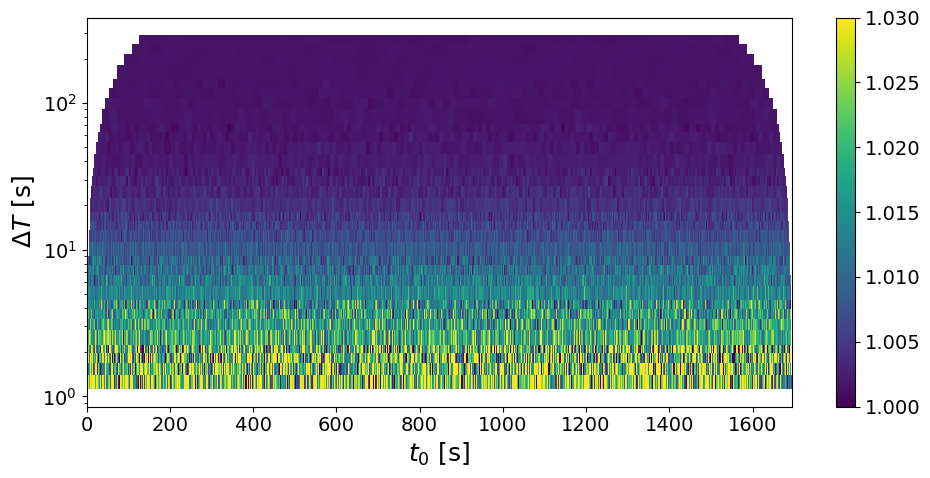

In [176]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 8
upper_corr = None
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

#### Fit

,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.17,0.03,5.87879,0.104011,1.769252,0.731022,0.009342,1.277925,0.027545,0.000279,1.012219,1.001525,0.000012,0.001243,3.565042


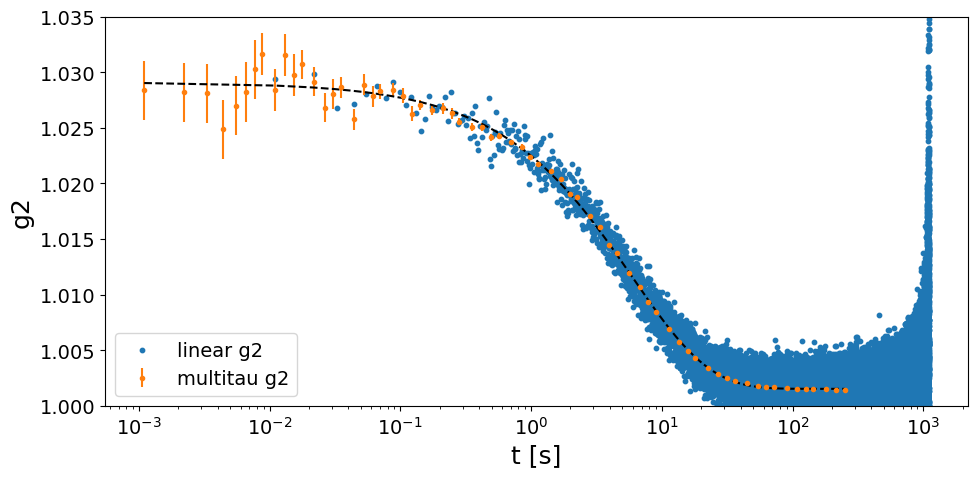

In [177]:
##################
t1_fit = 0
t2_fit = None
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.03)
#params.add('y0', value=1.0023, vary=False)
##############################################

if t1_fit is None: t1_fit = 0
if t2_fit is None: t2_fit = 1e100

g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])

# DATA PLOTS
plt.figure(figsize=(10,5))
plt.scatter(g2[0], g2[1], s=10, c='C0', label='linear g2')
plt.errorbar(g2mt[0], g2mt[1], yerr=g2mt[2], fmt = 'o', c='C1', label='multitau g2', markersize=3)

tmask = (t1_fit<g2mt[0])*(g2mt[0]<t2_fit)
x, y, dy =  g2mt[0][tmask], g2mt[1][tmask], g2mt[2][tmask]

# FIT
fit = model.fit(y, params, t=x, method='least_squares', weights=1/dy)
g2fit.loc[0] = [Q_notebook, dQ_notebook,
                fit.params['tau'].value, fit.params['tau'].stderr, fit.params['tau'].stderr/fit.params['tau'].value*100,
                fit.params['beta'].value, fit.params['beta'].stderr, fit.params['beta'].stderr/fit.params['beta'].value*100,
                fit.params['c'].value, fit.params['c'].stderr, fit.params['c'].stderr/fit.params['c'].value*100,
                fit.params['y0'].value, fit.params['y0'].stderr, fit.params['y0'].stderr/fit.params['y0'].value*100,
                fit.redchi,]

display(g2fit)

# PLOT FIT
x = np.arange(np.min(g2mt[0]), np.max(g2mt[0]), 1e-2)
y = fit.eval(t=x)
plt.plot(x, y, c='black', linestyle='--')
if t1_fit!=0:     plt.axvline(t1_fit, color='red', linestyle='--')
if t2_fit!=1e100: plt.axvline(t2_fit, color='red', linestyle='--')

plt.xlabel('t [s]')
plt.ylabel('g2')
plt.xscale('log')
#plt.xlim(0,50)
plt.ylim(1, 1.035)
plt.legend()
plt.tight_layout(); plt.show()

# Other curve for Baldis plots!

## First T (660C)

In [8]:
#######################################
sample_name = 'GeO2_7_660C'
Ndataset = 1
Nscan = 4
Nfi, Nff = None, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=50, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 10799904
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 198.00 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/2160 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/2160 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00014.h5 (15/2160 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/2160 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/2160 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/2160 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/2160 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/2160 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00012.h5 (13/2160 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/2160 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/2160 loops)
	 -> loading file eiger4m_v2_sparse_f

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  2839087 pixels (of 4471016 => 63.5 %)
# of pixels below Ith_low treshold ->  120878 pixels (of 4471016 => 2.7 %)
################################################################################



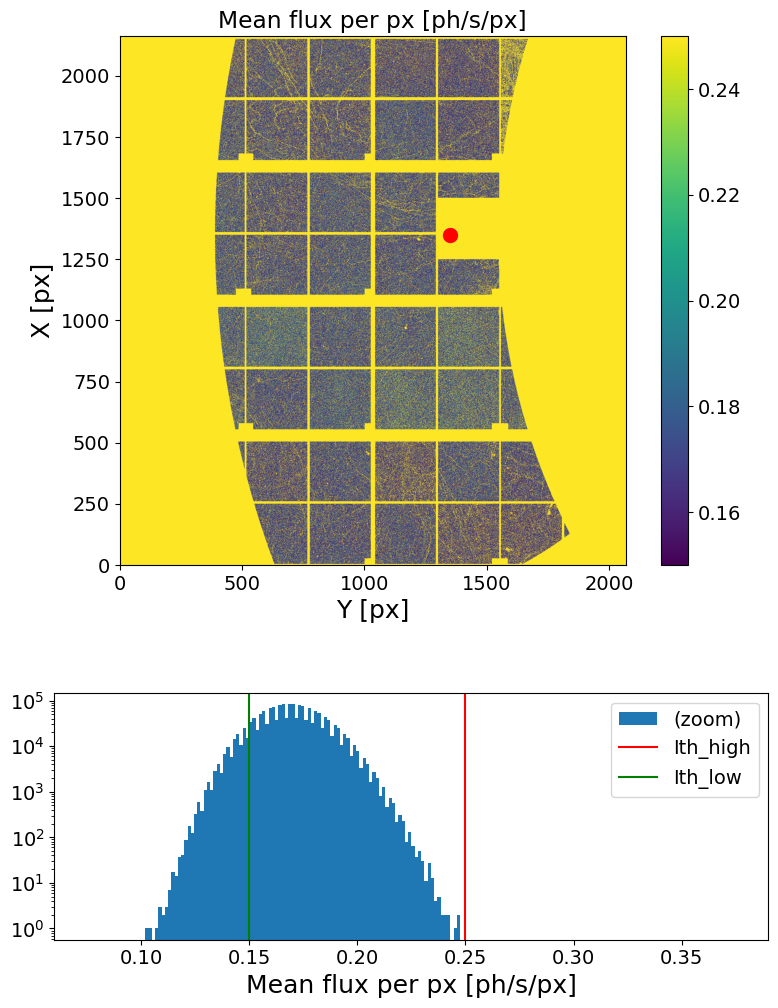

In [9]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=.15, Ith_high=.25, Nff=1_000_000, load_mask=load_mask)

### Intensity analysis

In [10]:
####################
Lbin = 10
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))

<SecondaryAxis: >

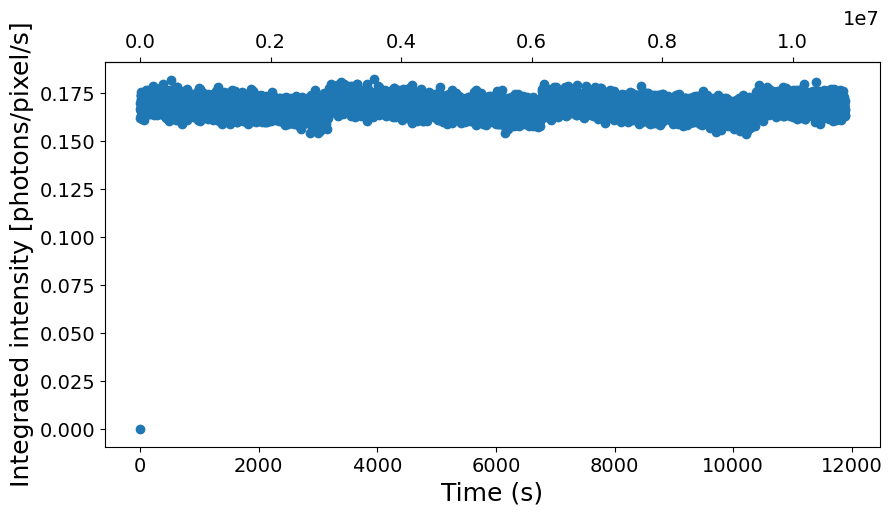

In [11]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Multitau correlation of damaged-vGeO2

In [12]:
##### INPUTS #####
Nfi = 1000
Nff = None #Nfi +  20 * 2**1
sparse_depth = 15
ch_depth = 3
##################

G2tmtA = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff, keep_symmetric=False)
g2mtA = np.vstack(XPCS.get_g2mt(itime, G2tmtA))

Nff set to 10781672 => (Nff-Nfi) = 329*2^sparse_depth, thrown frames = 18232 (0.17%)
Loading frames ...
Done! (elapsed time = 33.76 s)
	 | 10780672 frames X 1631929 pixels
	 | sparsity = 1.85e-04
	 | memory usage (sparse.csr_array @ float32) = 36.398 GB
Computing sparse multitau G2t...


100%|██████████| 329/329 [14:47<00:00,  2.70s/it]


Done! (elapsed time = 888.4 s)
Computing dense multitau G2t...
	-> computing channels on 1316 frames ...
	-> computing channels on 658 frames ...
	-> computing channels on 329 frames ...
	-> computing channels on 164 frames ...
	-> computing channels on 82 frames ...
	-> computing channels on 41 frames ...
	-> computing channels on 20 frames ...
	-> computing channels on 10 frames ...
Done! (elapsed time = 32.19 s)


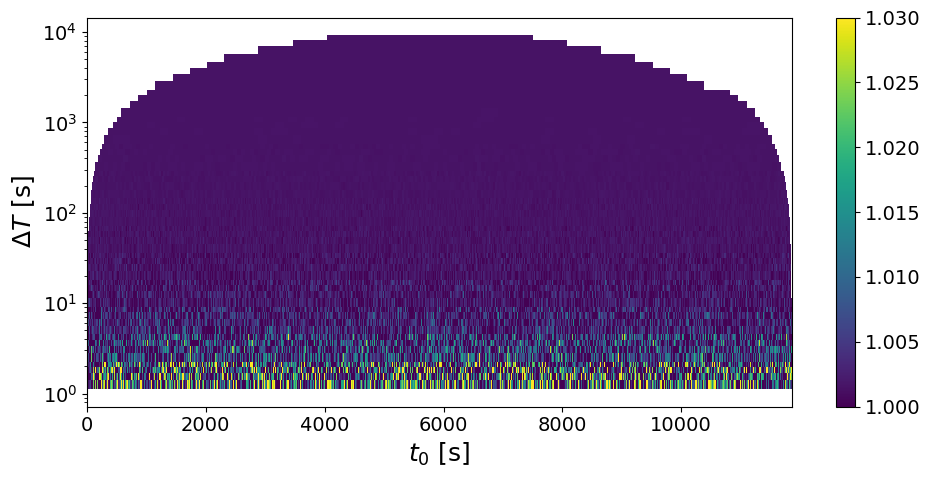

In [13]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 8
upper_corr = None
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmtA, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

## Second T (30C)

In [16]:
#######################################
sample_name = 'GeO2_7_30C'
Ndataset = 3
Nscan = 3
Nfi, Nff = None, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=50, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 33.01 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00038.h5 (39/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00046.h5 (47/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00041.

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  2912502 pixels (of 4471016 => 65.14 %)
# of pixels below Ith_low treshold ->  3 pixels (of 4471016 => 0.0 %)
################################################################################



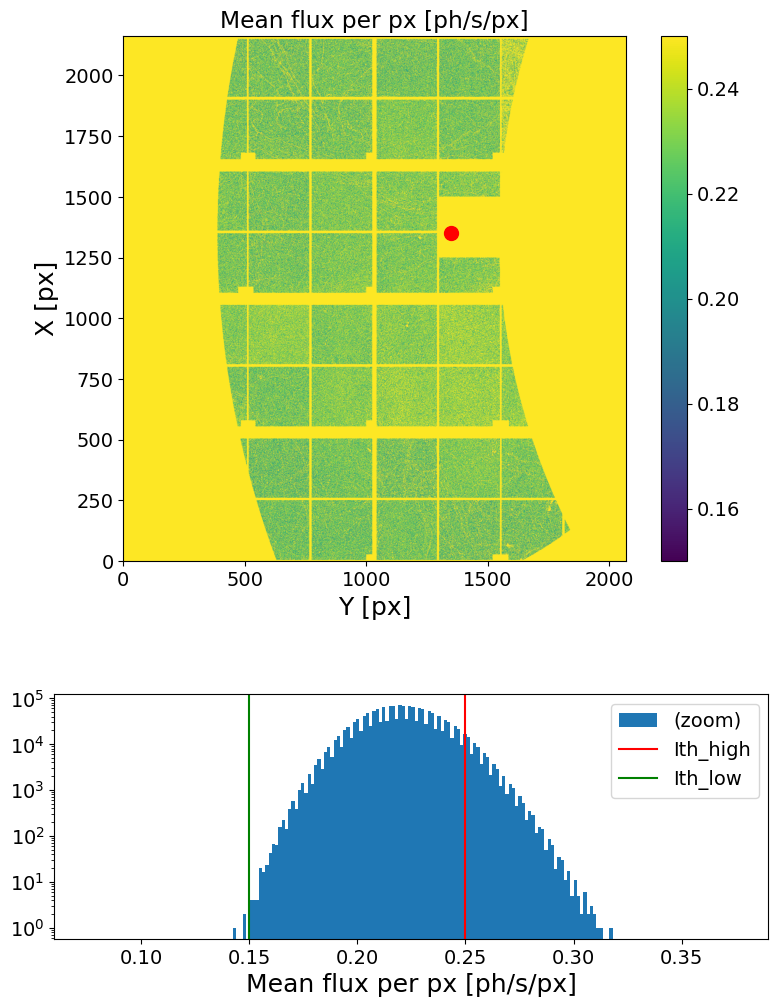

In [17]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=.15, Ith_high=.25, Nff=1_000_000, load_mask=load_mask)

### Intensity analysis

In [18]:
####################
Lbin = 10
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))

<SecondaryAxis: >

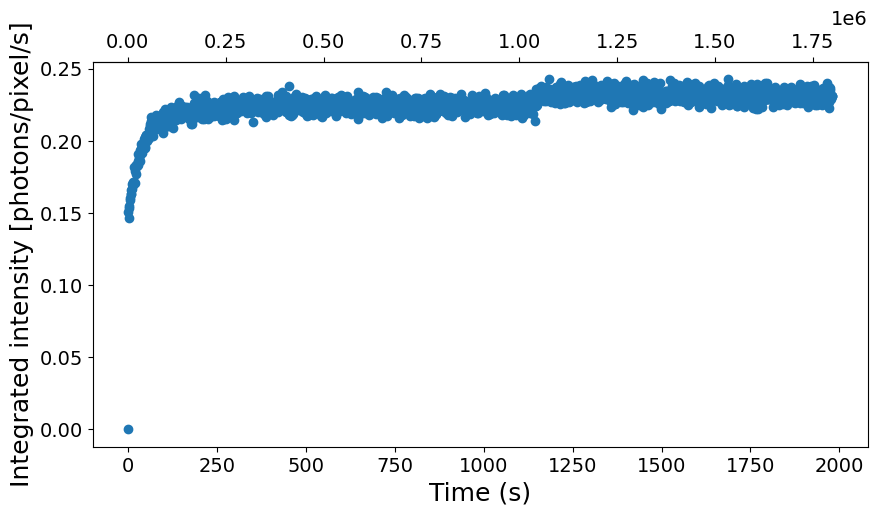

In [19]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Multitau correlation of damaged-vGeO2

In [20]:
##### INPUTS #####
Nfi = int(.25e6)
Nff = None #Nfi +  20 * 2**1
sparse_depth = 14
ch_depth = 3
##################

G2tmtB = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff, keep_symmetric=False)
g2mtB = np.vstack(XPCS.get_g2mt(itime, G2tmtB))

Nff set to 1790096 => (Nff-Nfi) = 94*2^sparse_depth, thrown frames = 10192 (0.66%)
Loading frames ...
Done! (elapsed time = 5.41 s)
	 | 1540096 frames X 1631929 pixels
	 | sparsity = 2.51e-04
	 | memory usage (sparse.csr_array @ float32) = 7.052 GB
Computing sparse multitau G2t...


100%|██████████| 94/94 [01:40<00:00,  1.06s/it]


Done! (elapsed time = 100.22 s)
Computing dense multitau G2t...
	-> computing channels on 376 frames ...
	-> computing channels on 188 frames ...
	-> computing channels on 94 frames ...
	-> computing channels on 47 frames ...
	-> computing channels on 23 frames ...
	-> computing channels on 11 frames ...
Done! (elapsed time = 8.57 s)


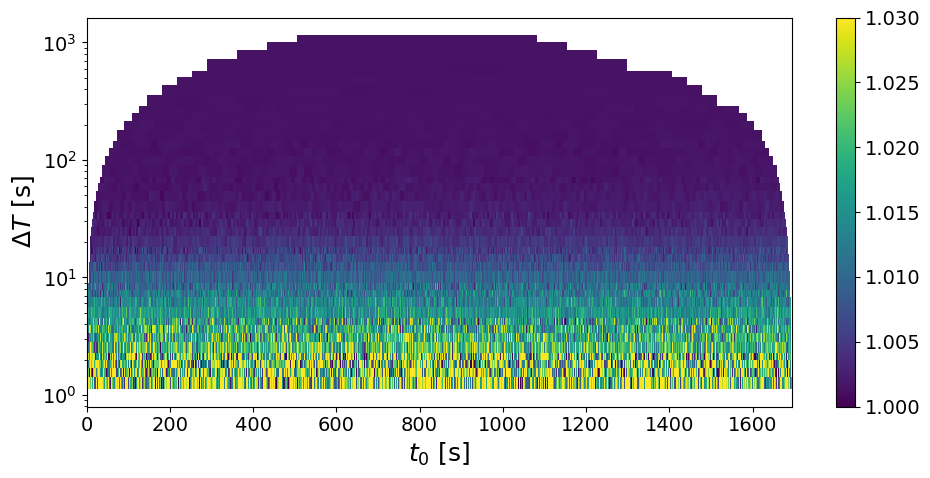

In [21]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 8
upper_corr = None
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmtB, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

## Comparison plot

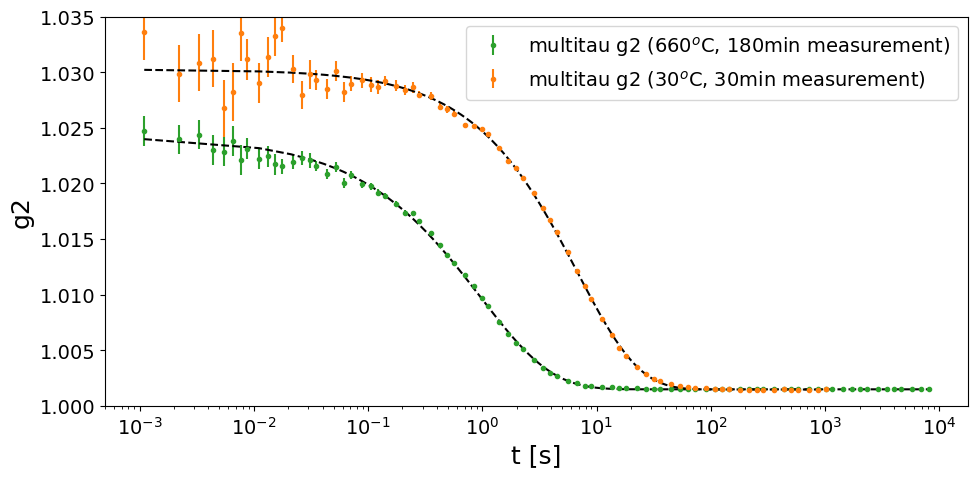

In [27]:
##################
t1_fit = 0
t2_fit = None
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.03)
#params.add('y0', value=1.0023, vary=False)
##############################################

if t1_fit is None: t1_fit = 0
if t2_fit is None: t2_fit = 1e100

g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])

# DATA PLOTS
plt.figure(figsize=(10,5))

### PLOT FIT g2A
plt.errorbar(g2mtA[0], g2mtA[1], yerr=g2mtA[2], fmt = 'o', c='C2', label='multitau g2 (660$^o$C, 180min measurement)', markersize=3)

tmask = (t1_fit<g2mtA[0])*(g2mtA[0]<t2_fit)
x, y, dy =  g2mtA[0][tmask], g2mtA[1][tmask], g2mtA[2][tmask]

# FIT
fitA = model.fit(y, params, t=x, method='least_squares', weights=1/dy)

# PLOT FIT
x = np.arange(np.min(g2mtA[0]), np.max(g2mtA[0]), 1e-2)
y = fitA.eval(t=x)
plt.plot(x, y, c='black', linestyle='--')

##### PLOT FIT g2B
plt.errorbar(g2mtB[0], g2mtB[1], yerr=g2mtB[2], fmt = 'o', c='C1', label='multitau g2 (30$^o$C, 30min measurement)', markersize=3)

tmask = (t1_fit<g2mtB[0])*(g2mtB[0]<t2_fit)
x, y, dy =  g2mtB[0][tmask], g2mtB[1][tmask], g2mtB[2][tmask]

# FIT
fitB = model.fit(y, params, t=x, method='least_squares', weights=1/dy)

# PLOT FIT
x = np.arange(np.min(g2mtB[0]), np.max(g2mtB[0]), 1e-2)
y = fitB.eval(t=x)
plt.plot(x, y, c='black', linestyle='--')
plt.xlabel('t [s]')
plt.ylabel('g2')
plt.xscale('log')
#plt.xlim(0,50)
plt.ylim(1, 1.035)
plt.legend()
plt.tight_layout(); plt.show()